## 理论基础 
粒子群算法时计算智能领域除了蚁群算法，鱼群算法之外的一种群体智能的优化算法。该算法最早由Kennedy和Eberhart在1995年提出。该算法源于对鸟类捕食行为的研究，鸟类捕食时最简单有效的策略是搜寻当前距离食物最近的鸟的周围区域。  

其核心思想是用每个"粒子"代表问题的一个潜在解；粒子在解空间中飞行，根据自身经验和群体经验调整飞行方向；通过迭代不断更新粒子位置，最终收敛到最优解  

对于第 $i$ 个粒子在第 $t+1$ 次迭代时的速度更新：  
$$
\mathbf{v}_i(t+1) = w \cdot \mathbf{v}_i(t) + c_1 \cdot r_1 \cdot (\mathbf{pbest}_i - \mathbf{x}_i(t)) + c_2 \cdot r_2 \cdot (\mathbf{gbest} - \mathbf{x}_i(t))
$$  
位置更新公式:
$$
\mathbf{x}_i(t+1) = \mathbf{x}_i(t) + \mathbf{v}_i(t+1)
$$

其中 $c_1$ 和 $c_2$ 是非负的常数，称为加速度因子；  
其中 $r_1$ 和 $r_2$ 是位于 $[0,1]$ 的随机数；   
其中 $w$ 是惯性权重； 

通常我们会对位置和速度的上下限做出约束： $[-X_{max},X_{max}]$ 和 $[-V_{max},V_{max}]$

## 实例计算  
本案例寻优的非线性函数为 $f(x,y) = \frac{\sin\left(\sqrt{x^2 + y^2}\right)}{\sqrt{x^2 + y^2}} + e^{\frac{\cos(2\pi x) + \cos(2\pi y)}{2}} - e$   
为该函数画出图像，可以发现该函数有许多局部极大值点，极限位置在 $(0,0)$ ，取得最大值约为1

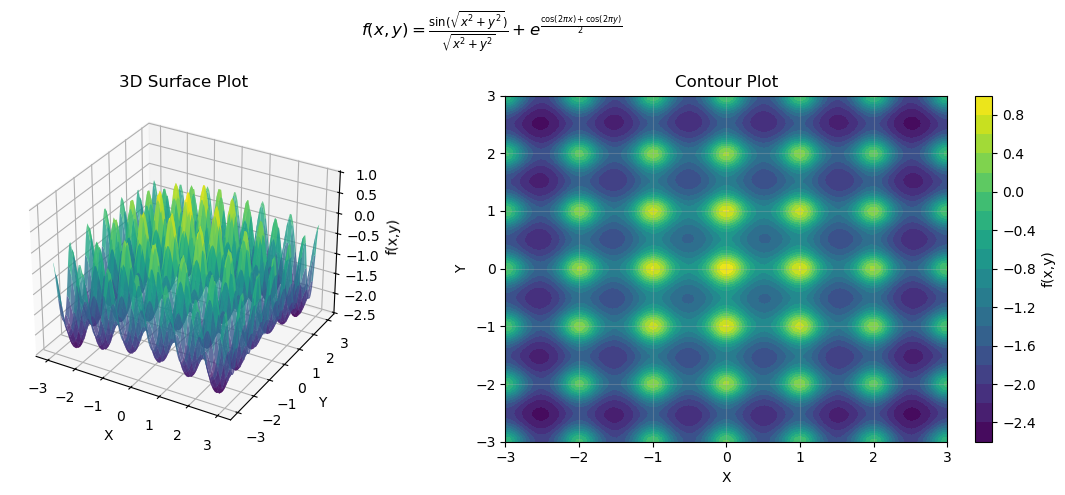

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 定义函数
def f(x, y):
    r = np.sqrt(x**2 + y**2)
    result = np.ones_like(r)
    mask = r != 0
    result[mask] = np.sin(r[mask]) / r[mask]
    result += np.exp((np.cos(2*np.pi*x) + np.cos(2*np.pi*y)) / 2)
    result -= np.e
    return result

# 生成数据
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# 创建图形
fig = plt.figure(figsize=(12, 5))

# 3D曲面图
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('3D Surface Plot')

# 等高线图
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, 20, cmap='viridis')
plt.colorbar(contour, ax=ax2, label='f(x,y)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Contour Plot')
ax2.grid(True, alpha=0.3)

plt.suptitle(r'$f(x,y)=\frac{\sin(\sqrt{x^2+y^2})}{\sqrt{x^2+y^2}}+e^{\frac{\cos(2\pi x)+\cos(2\pi y)}{2}}$')
plt.tight_layout()
plt.show()

## 算法思路与步骤
基于PSO算法的思路如下：
1. 初始化粒子速度和位置  
2. 粒子适应度值计算
3. 寻找个体极值和群体极值
4. 速度更新和位置更新
5. 粒子适应度值计算
6. 个体极值和群体极值更新
7. 判断是否满足终止条件，若不满足返回4
8. 结束  

本例子中适应度函数为函数表达式，适应度值为函数值。种群粒子数为20，每个粒子的维数为2，迭代次数为300

In [2]:
import numpy as np
# 定义参数
c_1 = 1.49445
c_2 = 1.49445        # 速度更新参数

max_gen = 300        # 最大迭代次数
size_pop = 20        # 种群规模

pop_max, pop_min = 2, -2  # 搜索空间边界
v_max, v_min = 0.5, -0.5      # 速度边界

In [4]:
# 本例中使用的适应度函数
def fitness_function(position):
    if len(position) == 2:
        x, y = position[0], position[1]
        r = np.sqrt(x**2 + y**2)
        if r == 0:
            return 1
        else:
            return (np.sin(r) / r) + np.exp((np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)) / 2) - np.e 

In [5]:
# 计算种群的适应度
def evaluate_population(pop_position):
    fitness_values = np.array([fitness_function(pos) for pos in pop_position])
    return fitness_values

In [7]:
# 更新个体和种群极值
def update_bests(pop_position, pop_fitness, pbest_position, pbest_fitness, gbest_position, gbest_fitness):
    for i in range(pop_position.shape[0]):
        if pop_fitness[i] > pbest_fitness[i]:
            pbest_fitness[i] = pop_fitness[i]
            pbest_position[i] = pop_position[i].copy()
    max_index = np.argmax(pbest_fitness)
    if pbest_fitness[max_index] > gbest_fitness:
        gbest_fitness = pbest_fitness[max_index]
        gbest_position = pbest_position[max_index].copy()
    return pbest_position, pbest_fitness, gbest_position, gbest_fitness

In [9]:
import numpy as np
# 初始化种群
pop_position = np.random.uniform(pop_min, pop_max, (size_pop, 2))  # 位置
pop_velocity = np.random.uniform(v_min, v_max, (size_pop, 2))  # 速度
pop_fitness = evaluate_population(pop_position)  # 适应度

# 初始化个体最优和全局最优
pbest_position = pop_position.copy()
pbest_fitness = pop_fitness.copy()
max_index = np.argmax(pbest_fitness)
gbest_position = pbest_position[max_index]
gbest_fitness = pbest_fitness[max_index]

In [11]:
# 迭代寻优
for gen in range(max_gen):
    for i in range(size_pop):
        r_1, r_2 = np.random.rand(), np.random.rand()
        # 更新速度
        pop_velocity[i] = (pop_velocity[i] +
                           c_1 * r_1 * (pbest_position[i] - pop_position[i]) +
                           c_2 * r_2 * (gbest_position - pop_position[i]))
        # 限制速度边界
        pop_velocity[i] = np.clip(pop_velocity[i], v_min, v_max)
        # 更新位置
        pop_position[i] = pop_position[i] + pop_velocity[i]
        # 限制位置边界
        pop_position[i] = np.clip(pop_position[i], pop_min, pop_max)
    # 计算适应度
    pop_fitness = evaluate_population(pop_position)
    # 更新个体和全局最优
    pbest_position, pbest_fitness, gbest_position, gbest_fitness = update_bests(
        pop_position, pop_fitness, pbest_position, pbest_fitness, gbest_position, gbest_fitness)
    if (gen + 1) % 10 == 0:
        print(f'Generation {gen + 1}, Global Best Fitness: {gbest_fitness:.6f}')

Generation 10, Global Best Fitness: 0.999982
Generation 20, Global Best Fitness: 0.999982
Generation 30, Global Best Fitness: 0.999982
Generation 40, Global Best Fitness: 0.999982
Generation 50, Global Best Fitness: 0.999983
Generation 60, Global Best Fitness: 0.999983
Generation 70, Global Best Fitness: 0.999983
Generation 80, Global Best Fitness: 0.999983
Generation 90, Global Best Fitness: 0.999983
Generation 100, Global Best Fitness: 0.999983
Generation 110, Global Best Fitness: 0.999983
Generation 120, Global Best Fitness: 0.999983
Generation 130, Global Best Fitness: 0.999983
Generation 140, Global Best Fitness: 0.999983
Generation 150, Global Best Fitness: 0.999983
Generation 160, Global Best Fitness: 0.999983
Generation 170, Global Best Fitness: 0.999983
Generation 180, Global Best Fitness: 0.999983
Generation 190, Global Best Fitness: 0.999999
Generation 200, Global Best Fitness: 0.999999
Generation 210, Global Best Fitness: 0.999999
Generation 220, Global Best Fitness: 0.9999

## 一点改进
Shi.Y首先首先将惯性权重 $w$ 引入PSO算法中，并分析指出一个较大的惯性权值有利于全局搜索，而一个较小的惯性权值则更利于局部搜索  
$$
w(k) = w_{start}(w_{start} - w_{end})(T_{max} - k) / T_{max}
$$
$w$一般取0.4到0.9